In [3]:
import pandas as pd
import sys

print("Python:", sys.version)
print("Pandas:", pd.__version__)

Python: 3.13.15 (main, Sep  1 2026, 14:16:48) [MSC v.1944 64 bit (AMD64)]
Pandas: 3.0.5


In [4]:
from pathlib import Path

data_path = Path("../data")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

In [5]:
from pathlib import Path
print(Path.cwd())

c:\Users\user777\Desktop\Conclusion Intelegence project\SpikupCapstone2026_CYRV\notebooks


In [6]:
data_path = Path("../data")

print("Data folder exists:", data_path.exists())

for item in data_path.iterdir():
    print(item.name)

Data folder exists: True
cyrv
README.md


In [7]:
data_path = Path("../data/cyrv")

csv_files = list(data_path.glob("*.csv"))

for file in csv_files:
    print(file.name)

CYRV_customers_dataset.csv
CYRV_geolocation_dataset.csv
CYRV_orders_dataset.csv
CYRV_order_items_dataset.csv
CYRV_order_payments_dataset.csv
CYRV_order_reviews_dataset.csv
CYRV_products_dataset.csv
CYRV_sellers_dataset.csv
product_category_name_translation.csv


In [8]:
file_info = []

for file in csv_files:
    file_info.append({
        "file": file.name,
        "size_mb": round(file.stat().st_size / (1024 * 1024), 2)
    })

pd.DataFrame(file_info).sort_values("size_mb", ascending=False)

,file,size_mb
1,CYRV_geolocation_dataset.csv,59.39
2,CYRV_orders_dataset.csv,16.93
3,CYRV_order_items_dataset.csv,14.83
5,CYRV_order_reviews_dataset.csv,13.78
0,CYRV_customers_dataset.csv,8.71
4,CYRV_order_payments_dataset.csv,5.61
6,CYRV_products_dataset.csv,2.30
7,CYRV_sellers_dataset.csv,0.17
8,product_category_name_translation.csv,0.00


In [9]:
customers = pd.read_csv(data_path / "CYRV_customers_dataset.csv")
orders = pd.read_csv(data_path / "CYRV_orders_dataset.csv")
order_items = pd.read_csv(data_path / "CYRV_order_items_dataset.csv")
payments = pd.read_csv(data_path / "CYRV_order_payments_dataset.csv")
reviews = pd.read_csv(data_path / "CYRV_order_reviews_dataset.csv")
products = pd.read_csv(data_path / "CYRV_products_dataset.csv")
sellers = pd.read_csv(data_path / "CYRV_sellers_dataset.csv")
category_translation = pd.read_csv(
    data_path / "product_category_name_translation.csv"
)

print("Datasets loaded successfully ✅")

Datasets loaded successfully ✅


In [10]:
datasets = {
    "customers": customers,
    "orders": orders,
    "order_items": order_items,
    "payments": payments,
    "reviews": reviews,
    "products": products,
    "sellers": sellers,
    "category_translation": category_translation
}

summary = []

for name, df in datasets.items():
    summary.append({
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_values": df.isna().sum().sum(),
        "duplicate_rows": df.duplicated().sum()
    })

summary_df = pd.DataFrame(summary)
summary_df

,dataset,rows,columns,missing_values,duplicate_rows
0,customers,99441,5,0,0
1,orders,99441,8,4908,0
2,order_items,112650,7,0,0
3,payments,103886,5,0,0
4,reviews,99224,7,145903,0
5,products,32951,9,2448,0
6,sellers,3095,4,0,0
7,category_translation,71,2,0,0


In [11]:
for name in ["orders", "reviews", "products"]:
    df = datasets[name]
    
    print(f"\n{name.upper()}")
    print("-" * 40)
    
    missing = df.isna().sum()
    missing = missing[missing > 0]
    
    print(missing)


ORDERS
----------------------------------------
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

REVIEWS
----------------------------------------
review_comment_title      87656
review_comment_message    58247
dtype: int64

PRODUCTS
----------------------------------------
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64


In [12]:
orders_missing_by_status = (
    orders.groupby("order_status")
    .agg(
        total_orders=("order_id", "size"),
        missing_approved=("order_approved_at", lambda x: x.isna().sum()),
        missing_carrier_date=("order_delivered_carrier_date", lambda x: x.isna().sum()),
        missing_customer_date=("order_delivered_customer_date", lambda x: x.isna().sum())
    )
    .sort_values("total_orders", ascending=False)
)

orders_missing_by_status

,total_orders,missing_approved,missing_carrier_date,missing_customer_date
order_status,,,,
delivered,96478,14,2,8
shipped,1107,0,0,1107
canceled,625,141,550,619
unavailable,609,0,609,609
invoiced,314,0,314,314
processing,301,0,301,301
created,5,5,5,5
approved,2,0,2,2


In [13]:
delivered_issues = orders[
    (orders["order_status"] == "delivered") &
    (
        orders["order_approved_at"].isna() |
        orders["order_delivered_carrier_date"].isna() |
        orders["order_delivered_customer_date"].isna()
    )
]

delivered_issues

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,ec05a6d8558c6455f0cbbd8a420ad34f,delivered,2017-11-28 17:44:07,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN,2017-12-18 00:00:00
5323,e04abd8149ef81b95221e88f6ed9ab6a,2127dc6603ac33544953ef05ec155771,delivered,2017-02-18 14:40:00,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33,2017-03-17 00:00:00
16567,8a9adc69528e1001fc68dd0aaebbb54a,4c1ccc74e00993733742a3c786dc3c1f,delivered,2017-02-18 12:45:31,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06,2017-03-21 00:00:00
19031,7013bcfc1c97fe719a7b5e05e61c12db,2941af76d38100e0f8740a374f1a5dc3,delivered,2017-02-18 13:29:47,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38,2017-03-17 00:00:00
20618,f5dd62b788049ad9fc0526e3ad11a097,5e89028e024b381dc84a13a3570decb4,delivered,2018-06-20 06:58:43,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN,2018-07-16 00:00:00
22663,5cf925b116421afa85ee25e99b4c34fb,29c35fc91fc13fb5073c8f30505d860d,delivered,2017-02-18 16:48:35,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47,2017-03-31 00:00:00
23156,12a95a3c06dbaec84bcfb0e2da5d228a,1e101e0daffaddce8159d25a8e53f2b2,delivered,2017-02-17 13:05:55,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19,2017-03-20 00:00:00
26800,c1d4211b3dae76144deccd6c74144a88,684cb238dc5b5d6366244e0e0776b450,delivered,2017-01-19 12:48:08,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01,2017-03-01 00:00:00
38290,d69e5d356402adc8cf17e08b5033acfb,68d081753ad4fe22fc4d410a9eb1ca01,delivered,2017-02-19 01:28:47,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58,2017-03-27 00:00:00
39334,d77031d6a3c8a52f019764e68f211c69,0bf35cac6cc7327065da879e2d90fae8,delivered,2017-02-18 11:04:19,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23,2017-03-22 00:00:00


In [14]:
print("Number of delivered orders with any missing delivery-related date:")
print(len(delivered_issues))

Number of delivered orders with any missing delivery-related date:
23


In [15]:
delivered_issues[
    [
        "order_id",
        "order_status",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
]

,order_id,order_status,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,delivered,2017-11-28 17:56:40,2017-11-30 18:12:23,NaN
5323,e04abd8149ef81b95221e88f6ed9ab6a,delivered,NaN,2017-02-23 12:04:47,2017-03-01 13:25:33
16567,8a9adc69528e1001fc68dd0aaebbb54a,delivered,NaN,2017-02-23 09:01:52,2017-03-02 10:05:06
19031,7013bcfc1c97fe719a7b5e05e61c12db,delivered,NaN,2017-02-22 16:25:25,2017-03-01 08:07:38
20618,f5dd62b788049ad9fc0526e3ad11a097,delivered,2018-06-20 07:19:05,2018-06-25 08:05:00,NaN
22663,5cf925b116421afa85ee25e99b4c34fb,delivered,NaN,2017-02-22 11:23:10,2017-03-09 07:28:47
23156,12a95a3c06dbaec84bcfb0e2da5d228a,delivered,NaN,2017-02-22 11:23:11,2017-03-02 11:09:19
26800,c1d4211b3dae76144deccd6c74144a88,delivered,NaN,2017-01-25 14:56:50,2017-01-30 18:16:01
38290,d69e5d356402adc8cf17e08b5033acfb,delivered,NaN,2017-02-23 03:11:48,2017-03-02 03:41:58
39334,d77031d6a3c8a52f019764e68f211c69,delivered,NaN,2017-02-23 07:23:36,2017-03-02 16:15:23


In [16]:
len(delivered_issues)

23

In [17]:
delivered_issues_check = delivered_issues[
    [
        "order_id",
        "order_approved_at",
        "order_delivered_carrier_date",
        "order_delivered_customer_date"
    ]
].copy()

delivered_issues_check["missing_approved"] = delivered_issues_check["order_approved_at"].isna()
delivered_issues_check["missing_carrier"] = delivered_issues_check["order_delivered_carrier_date"].isna()
delivered_issues_check["missing_customer"] = delivered_issues_check["order_delivered_customer_date"].isna()

delivered_issues_check[
    ["order_id", "missing_approved", "missing_carrier", "missing_customer"]
]

,order_id,missing_approved,missing_carrier,missing_customer
3002,2d1e2d5bf4dc7227b3bfebb81328c15f,False,False,True
5323,e04abd8149ef81b95221e88f6ed9ab6a,True,False,False
16567,8a9adc69528e1001fc68dd0aaebbb54a,True,False,False
19031,7013bcfc1c97fe719a7b5e05e61c12db,True,False,False
20618,f5dd62b788049ad9fc0526e3ad11a097,False,False,True
22663,5cf925b116421afa85ee25e99b4c34fb,True,False,False
23156,12a95a3c06dbaec84bcfb0e2da5d228a,True,False,False
26800,c1d4211b3dae76144deccd6c74144a88,True,False,False
38290,d69e5d356402adc8cf17e08b5033acfb,True,False,False
39334,d77031d6a3c8a52f019764e68f211c69,True,False,False


In [18]:
pattern_summary = (
    delivered_issues_check
    .groupby(
        ["missing_approved", "missing_carrier", "missing_customer"]
    )
    .size()
    .reset_index(name="number_of_orders")
    .sort_values("number_of_orders", ascending=False)
)

pattern_summary

,missing_approved,missing_carrier,missing_customer,number_of_orders
3,True,False,False,14
0,False,False,True,7
1,False,True,False,1
2,False,True,True,1


### Initial Data Quality Findings

- No fully duplicated rows were found in the main datasets.
- Most missing order dates are consistent with the order status.
- 23 delivered orders contain at least one missing delivery-related timestamp:
  - 14 missing approval date only
  - 7 missing customer delivery date only
  - 1 missing carrier date only
  - 1 missing both carrier and customer delivery dates
- Review title and message fields contain many missing values because written comments are optional.
- Product data contains 610 records with missing category/listing information and 2 records with missing physical dimensions.

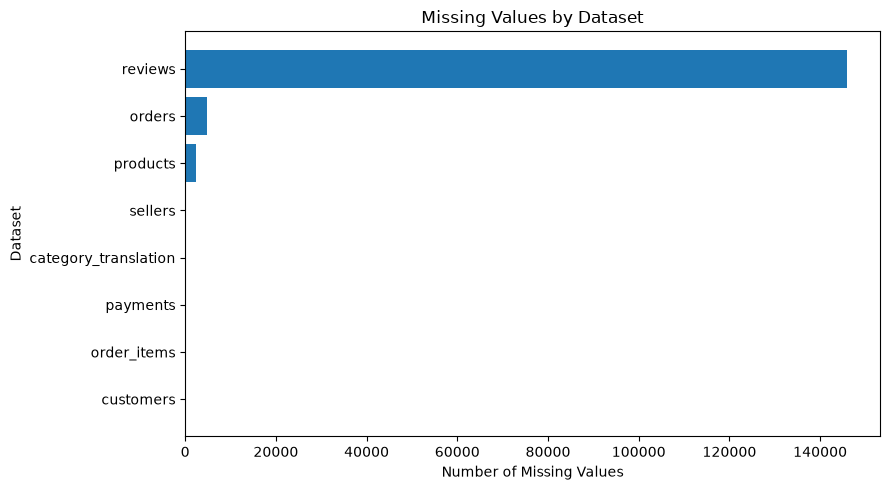

In [19]:
import matplotlib.pyplot as plt

plot_df = summary_df.sort_values("missing_values", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(plot_df["dataset"], plot_df["missing_values"])

plt.title("Missing Values by Dataset")
plt.xlabel("Number of Missing Values")
plt.ylabel("Dataset")

plt.tight_layout()
plt.show()

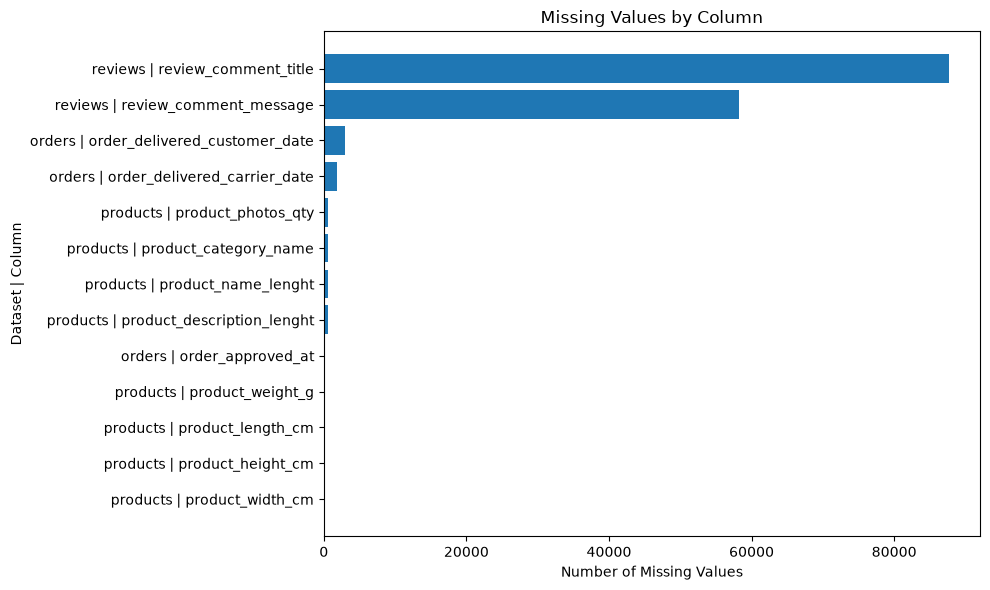

In [20]:
# Missing values by column
missing_by_column = []

for dataset_name, df in datasets.items():
    missing = df.isnull().sum()
    
    for column, count in missing.items():
        if count > 0:
            missing_by_column.append({
                "dataset": dataset_name,
                "column": column,
                "missing_values": count
            })

missing_columns_df = pd.DataFrame(missing_by_column)

# Sort largest to smallest
missing_columns_df = missing_columns_df.sort_values(
    "missing_values", ascending=True
)

plt.figure(figsize=(10, 6))

labels = (
    missing_columns_df["dataset"] + " | " +
    missing_columns_df["column"]
)

plt.barh(labels, missing_columns_df["missing_values"])

plt.title("Missing Values by Column")
plt.xlabel("Number of Missing Values")
plt.ylabel("Dataset | Column")

plt.tight_layout()
plt.show()

### Insight
- Most missing values are concentrated in the optional review text fields (`review_comment_title` and `review_comment_message`).
- Core transactional data is largely complete, with relatively few missing values in orders and products.

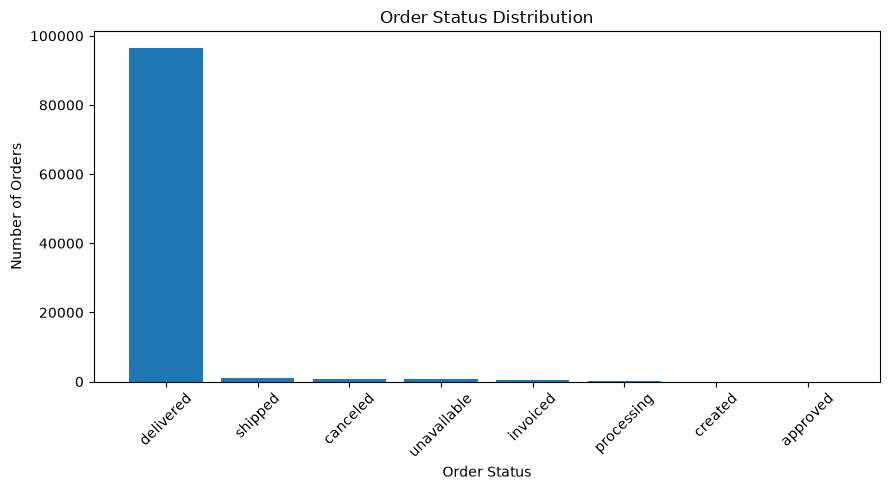

In [21]:
# Order Status Distribution
order_status_counts = datasets["orders"]["order_status"].value_counts()

plt.figure(figsize=(9, 5))
plt.bar(order_status_counts.index, order_status_counts.values)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
order_status_summary = datasets["orders"]["order_status"].value_counts().to_frame("orders")
order_status_summary["percentage"] = (
    order_status_summary["orders"] / order_status_summary["orders"].sum() * 100
).round(2)

order_status_summary

,orders,percentage
order_status,,
delivered,96478,97.02
shipped,1107,1.11
canceled,625,0.63
unavailable,609,0.61
invoiced,314,0.32
processing,301,0.30
created,5,0.01
approved,2,0.00


### Insight
- 97.02% of all orders were successfully delivered.
- Canceled and unavailable orders together represent only 1.24% of total orders.
- The dataset is therefore strongly dominated by completed deliveries.

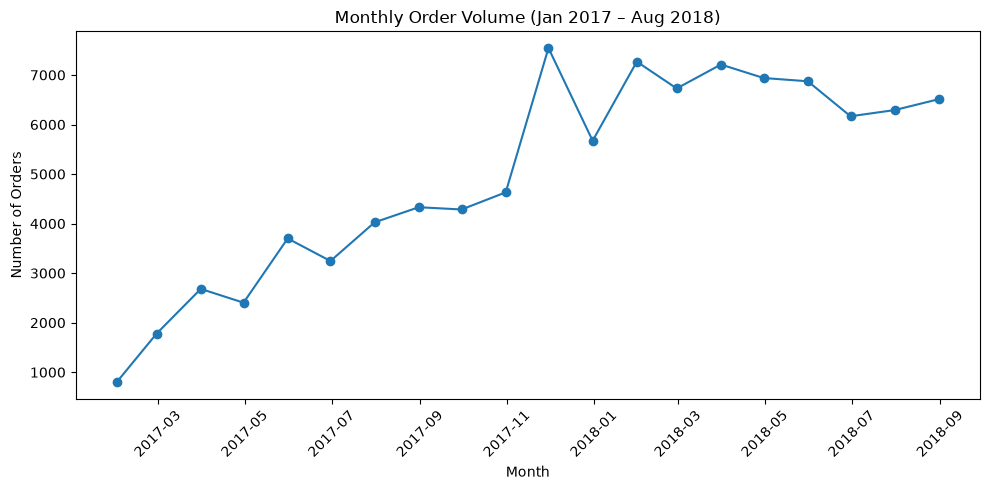

In [24]:
# Monthly Order Volume - Core Analysis Period
orders = datasets["orders"].copy()

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

# Use the analysis period defined during EDA
orders_core = orders[
    (orders["order_purchase_timestamp"] >= "2017-01-01") &
    (orders["order_purchase_timestamp"] < "2018-09-01")
].copy()

monthly_orders = (
    orders_core
    .set_index("order_purchase_timestamp")
    .resample("ME")
    .size()
)

plt.figure(figsize=(10, 5))
plt.plot(monthly_orders.index, monthly_orders.values, marker="o")

plt.title("Monthly Order Volume (Jan 2017 – Aug 2018)")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Insight
Order volume grew strongly throughout 2017, with a sharp peak in November.  
From early 2018, monthly order volume remained relatively stable at a higher level.

**Analysis period:** Jan 2017 – Aug 2018. Months outside this period were excluded because they contain incomplete activity.

In [25]:
duplicate_summary = []

for name, df in datasets.items():
    duplicate_summary.append({
        "dataset": name,
        "duplicate_rows": df.duplicated().sum()
    })

duplicate_summary_df = pd.DataFrame(duplicate_summary)

duplicate_summary_df

,dataset,duplicate_rows
0,customers,0
1,orders,0
2,order_items,0
3,payments,0
4,reviews,0
5,products,0
6,sellers,0
7,category_translation,0


### Insight – Duplicate Records

- No exact duplicate rows were found across the analyzed datasets.
- Therefore, duplicate removal is not required at this stage.

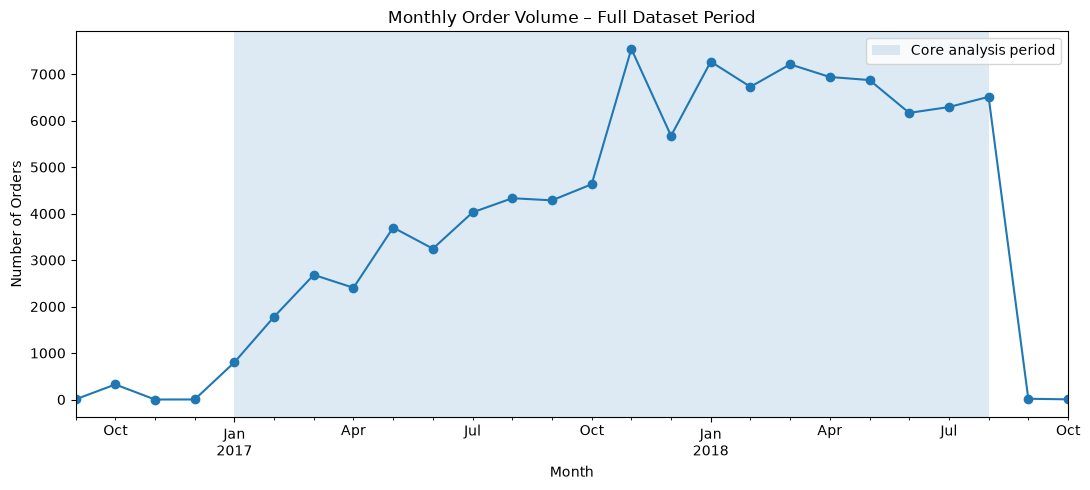

In [27]:
# Compare monthly order volume across the full dataset period

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

monthly_full = (
    orders
    .set_index("order_purchase_timestamp")
    .resample("MS")
    .size()
)

plt.figure(figsize=(11, 5))
monthly_full.plot(marker="o")

plt.axvspan(
    pd.Timestamp("2017-01-01"),
    pd.Timestamp("2018-08-31"),
    alpha=0.15,
    label="Core analysis period"
)

plt.title("Monthly Order Volume – Full Dataset Period")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.legend()
plt.tight_layout()
plt.show()

### Insight
Order activity is sparse before Jan 2017 and drops sharply after Aug 2018, indicating incomplete boundary periods. Therefore, Jan 2017–Aug 2018 was selected as the core analysis period for more reliable comparisons.